# Import Required Libraries
Import the necessary libraries, including pandas for data manipulation and matplotlib for plotting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data from CSV File
Use pandas to read the am.csv file into a DataFrame.

In [2]:
df = pd.read_csv('am.csv')
print(f"Data loaded successfully. Shape: {df.shape}")

Data loaded successfully. Shape: (38, 2)


# Explore the Dataset
Display the first few rows of the dataset and check the data types to understand the structure.

In [3]:
print("First few rows:")
print(df.head())
print("\nData info:")
print(df.info())

First few rows:
         vam        am
0 -53.825823  0.454381
1 -49.776669  0.598629
2 -45.797328  0.447169
3 -40.631166  0.620266
4 -40.910418  0.771727

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   vam     38 non-null     float64
 1   am      38 non-null     float64
dtypes: float64(2)
memory usage: 740.0 bytes
None


# Bootstrap Analysis
Generate bootstrap samples and fit each to am = Am*(vm+v05m)/(1-exp(-(vm+v05m)/zm)) to estimate parameter uncertainties.

In [4]:
from scipy.optimize import curve_fit
import numpy as np

# Define the fitting function
def am_function(vam, Am, v05m, zm):
    return Am * (vam + v05m) / (1 - np.exp(-(vam + v05m) / zm))

# Initial guesses for parameters
initial_guess = [0.1, 40, 10]

# Bootstrap parameters
n_bootstrap = 4000
n_samples = len(df)

# Arrays to store bootstrap results
Am_bootstrap = []
v05m_bootstrap = []
zm_bootstrap = []

# Perform bootstrap resampling
np.random.seed(42)  # For reproducibility

for i in range(n_bootstrap):
    # Resample with replacement
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    vam_resample = df['vam'].iloc[indices].values
    am_resample = df['am'].iloc[indices].values
    
    try:
        # Fit the resampled data
        popt_boot, _ = curve_fit(am_function, vam_resample, am_resample, p0=initial_guess)
        Am_bootstrap.append(popt_boot[0])
        v05m_bootstrap.append(popt_boot[1])
        zm_bootstrap.append(popt_boot[2])
    except:
        # Skip if fit fails
        continue

# Convert to numpy arrays
Am_bootstrap = np.array(Am_bootstrap)
v05m_bootstrap = np.array(v05m_bootstrap)
zm_bootstrap = np.array(zm_bootstrap)

print(f"Bootstrap Analysis Results (n={len(Am_bootstrap)} successful fits):")
print(f"\nParameter Am:")
print(f"  Mean = {np.mean(Am_bootstrap):.6f}")
print(f"  Std  = {np.std(Am_bootstrap):.6f}")
print(f"\nParameter v05m:")
print(f"  Mean = {np.mean(v05m_bootstrap):.6f}")
print(f"  Std  = {np.std(v05m_bootstrap):.6f}")
print(f"\nParameter zm:")
print(f"  Mean = {np.mean(zm_bootstrap):.6f}")
print(f"  Std  = {np.std(zm_bootstrap):.6f}")

/var/folders/nw/qqw2xvy17fv7cxtzjlhg366r0000gn/T/ipykernel_58218/2681552482.py:6: RuntimeWarning: overflow encountered in exp
  return Am * (vam + v05m) / (1 - np.exp(-(vam + v05m) / zm))
/var/folders/nw/qqw2xvy17fv7cxtzjlhg366r0000gn/T/ipykernel_58218/2681552482.py:31: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_boot, _ = curve_fit(am_function, vam_resample, am_resample, p0=initial_guess)


Bootstrap Analysis Results (n=4000 successful fits):

Parameter Am:
  Mean = 0.103663
  Std  = 0.008589

Parameter v05m:
  Mean = 39.464490
  Std  = 4.147962

Parameter zm:
  Mean = 6.027344
  Std  = 2.092637


# Plot Data with Bootstrap Mean Fit and Confidence Limits
Show the mean fit from bootstrap analysis with confidence intervals.

/var/folders/nw/qqw2xvy17fv7cxtzjlhg366r0000gn/T/ipykernel_58218/2681552482.py:6: RuntimeWarning: overflow encountered in exp
  return Am * (vam + v05m) / (1 - np.exp(-(vam + v05m) / zm))


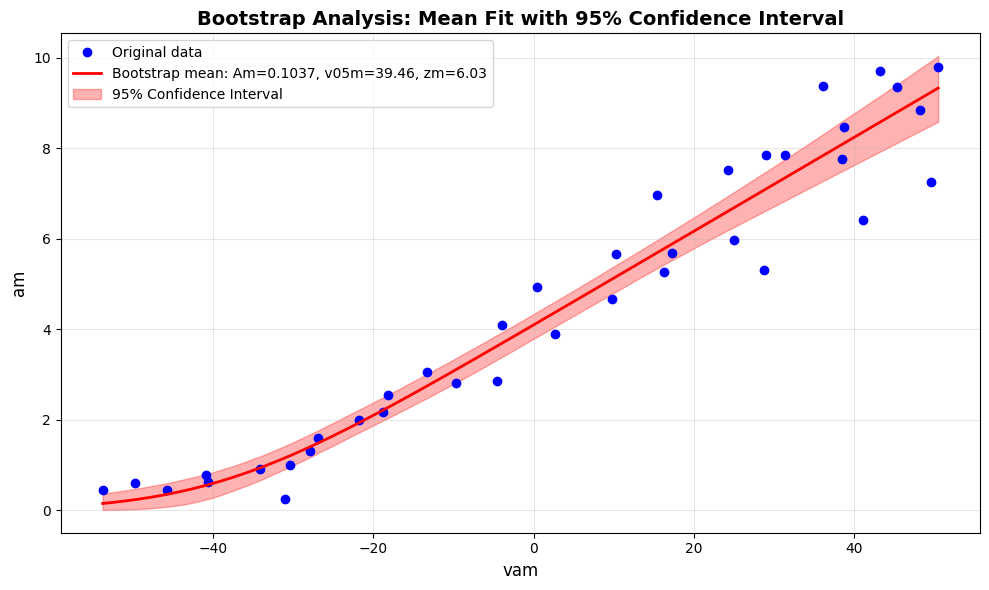

In [5]:
plt.figure(figsize=(10, 6))

# Plot original data
plt.plot(df['vam'], df['am'], 'o', label='Original data', markersize=6, color='blue')

# Generate smooth curve for mean bootstrap fit
vam_smooth = np.linspace(df['vam'].min(), df['vam'].max(), 200)
Am_mean = np.mean(Am_bootstrap)
v05m_mean = np.mean(v05m_bootstrap)
zm_mean = np.mean(zm_bootstrap)
am_mean = am_function(vam_smooth, Am_mean, v05m_mean, zm_mean)

# Calculate confidence limits (95% CI using 2.5th and 97.5th percentiles)
am_curves = np.array([am_function(vam_smooth, Am_bootstrap[i], v05m_bootstrap[i], zm_bootstrap[i])
                      for i in range(len(Am_bootstrap))])
am_lower = np.percentile(am_curves, 2.5, axis=0)
am_upper = np.percentile(am_curves, 97.5, axis=0)

# Plot mean fit and confidence interval
plt.plot(vam_smooth, am_mean, '-', linewidth=2, color='red', 
         label=f'Bootstrap mean: Am={Am_mean:.4f}, v05m={v05m_mean:.2f}, zm={zm_mean:.2f}')
plt.fill_between(vam_smooth, am_lower, am_upper, alpha=0.3, color='red', 
                 label='95% Confidence Interval')

plt.xlabel('vam', fontsize=12)
plt.ylabel('am', fontsize=12)
plt.title('Bootstrap Analysis: Mean Fit with 95% Confidence Interval', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Histograms of Bootstrap Parameters
Distribution of Am, v05m, and zm from bootstrap resampling.

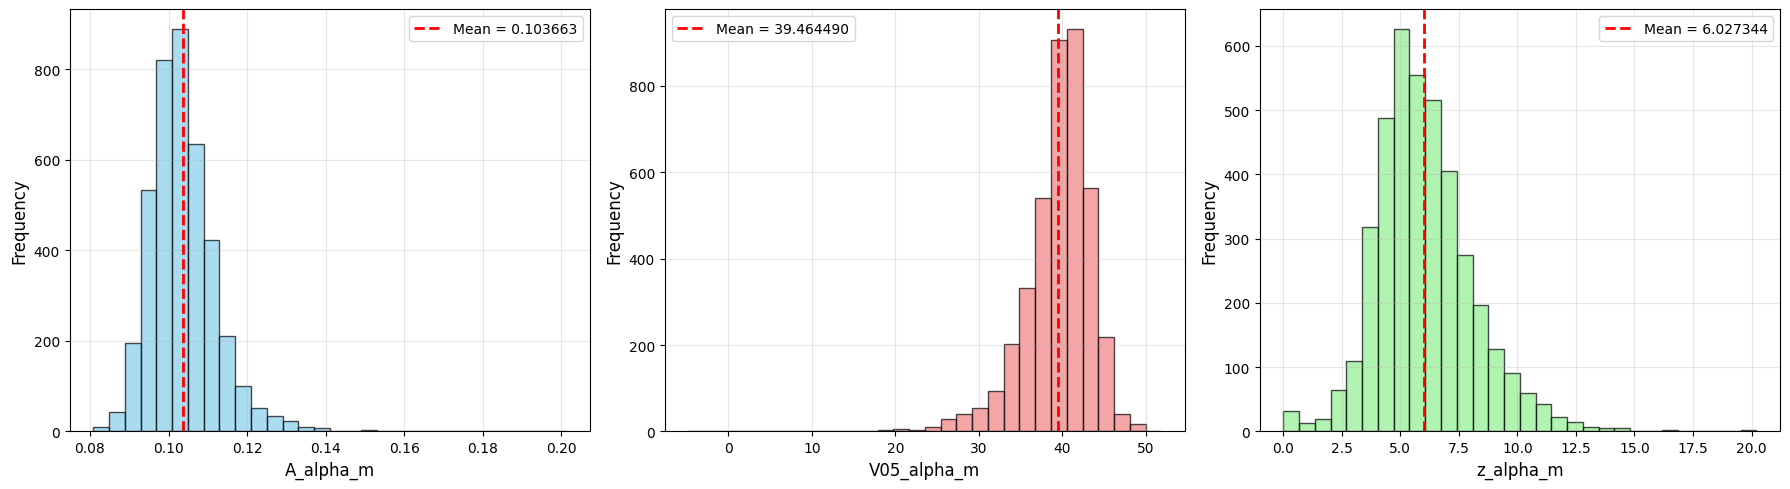

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of Am
axes[0].hist(Am_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(np.mean(Am_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(Am_bootstrap):.6f}')
axes[0].set_xlabel('A_alpha_m', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Histogram of v05m
axes[1].hist(v05m_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].axvline(np.mean(v05m_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(v05m_bootstrap):.6f}')
axes[1].set_xlabel('V05_alpha_m', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Histogram of zm
axes[2].hist(zm_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[2].axvline(np.mean(zm_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(zm_bootstrap):.6f}')
axes[2].set_xlabel('z_alpha_m', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Parameter Correlations
Scatter plots showing the relationships between fitted parameters from bootstrap samples.

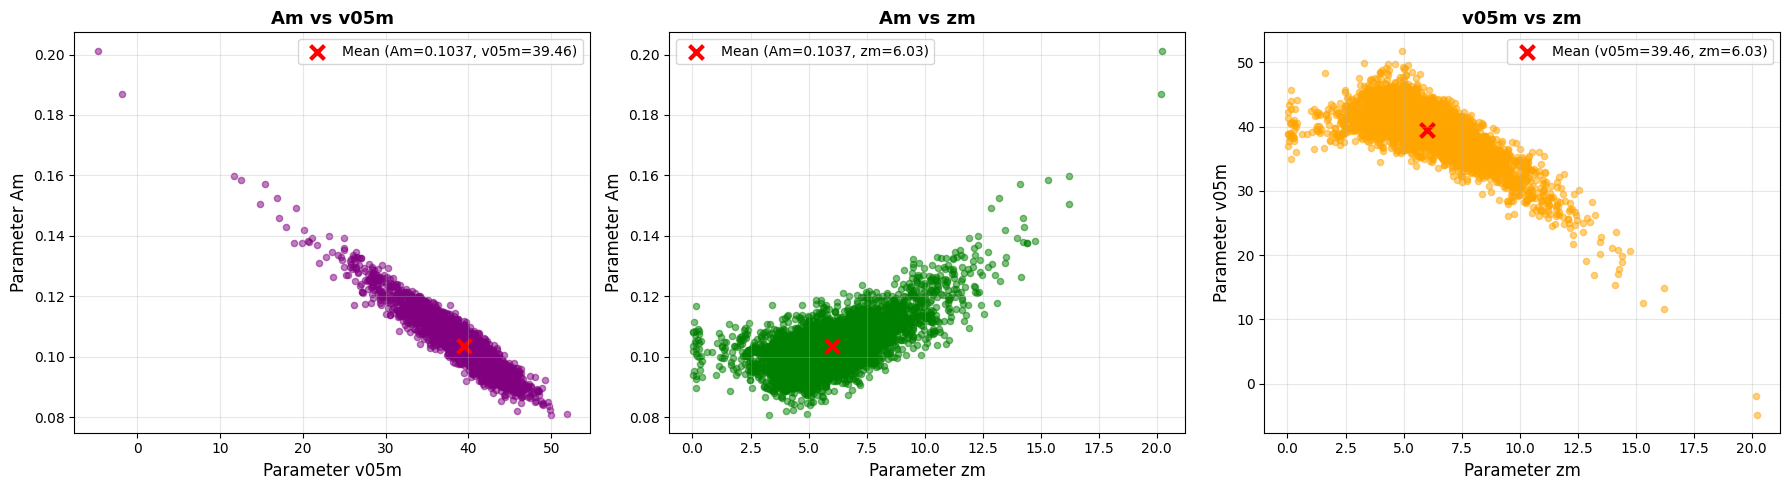


Correlation coefficients:
  Am vs v05m: -0.9427
  Am vs zm:   0.6720
  v05m vs zm: -0.7579


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calculate mean parameters
Am_mean = np.mean(Am_bootstrap)
v05m_mean = np.mean(v05m_bootstrap)
zm_mean = np.mean(zm_bootstrap)

# Scatter plot of Am vs v05m
axes[0].scatter(v05m_bootstrap, Am_bootstrap, alpha=0.5, s=20, color='purple')
axes[0].scatter(v05m_mean, Am_mean, color='red', s=100, marker='x', linewidths=3, 
                label=f'Mean (Am={Am_mean:.4f}, v05m={v05m_mean:.2f})')
axes[0].set_xlabel('Parameter v05m', fontsize=12)
axes[0].set_ylabel('Parameter Am', fontsize=12)
axes[0].set_title('Am vs v05m', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Scatter plot of Am vs zm
axes[1].scatter(zm_bootstrap, Am_bootstrap, alpha=0.5, s=20, color='green')
axes[1].scatter(zm_mean, Am_mean, color='red', s=100, marker='x', linewidths=3, 
                label=f'Mean (Am={Am_mean:.4f}, zm={zm_mean:.2f})')
axes[1].set_xlabel('Parameter zm', fontsize=12)
axes[1].set_ylabel('Parameter Am', fontsize=12)
axes[1].set_title('Am vs zm', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Scatter plot of v05m vs zm
axes[2].scatter(zm_bootstrap, v05m_bootstrap, alpha=0.5, s=20, color='orange')
axes[2].scatter(zm_mean, v05m_mean, color='red', s=100, marker='x', linewidths=3, 
                label=f'Mean (v05m={v05m_mean:.2f}, zm={zm_mean:.2f})')
axes[2].set_xlabel('Parameter zm', fontsize=12)
axes[2].set_ylabel('Parameter v05m', fontsize=12)
axes[2].set_title('v05m vs zm', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlation coefficients
corr_Am_v05m = np.corrcoef(Am_bootstrap, v05m_bootstrap)[0, 1]
corr_Am_zm = np.corrcoef(Am_bootstrap, zm_bootstrap)[0, 1]
corr_v05m_zm = np.corrcoef(v05m_bootstrap, zm_bootstrap)[0, 1]

print(f"\nCorrelation coefficients:")
print(f"  Am vs v05m: {corr_Am_v05m:.4f}")
print(f"  Am vs zm:   {corr_Am_zm:.4f}")
print(f"  v05m vs zm: {corr_v05m_zm:.4f}")